<center><h1>QBUS2820 - Predictive Analytics</h1></center>

# Tutorial 5 - Model Selection and Evaluation

In this tutorial we will continue working with the K-nearest neighbours regression method and the credit dataset to introduce model selection into the data analysis process. By using cross validation, we can pick the number of neighbours before generating predictions for the test data. 

This notebook relies on the following imports throughout. We will load new packages and functions in context to make clear what we are using them for. 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_context('notebook') # optimises picture for notebook viewing

### Data processing

We start by loading the dataset in the same way as before. 

In [10]:
data=pd.read_csv('credit.csv', index_col='Obs')
data.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
Obs,,,,,,,,,,,
1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


This time, let's do some additional processing to create dummy variables.

In [12]:
data['Male']=(data['Gender'] ==' Male').astype(int)
data['Student']=(data['Student'] =='Yes').astype(int)
data['Married']=(data['Married'] =='Yes').astype(int)
data['Caucasian']=(data['Ethnicity'] =='Caucasian').astype(int)
data['Asian']=(data['Ethnicity'] =='Asian').astype(int)
data=data.loc[:, data.dtypes!='object'] # discards the columns that are not numerical
data=data.drop('Rating', axis=1) # dropping rating because it is collinear with limit, as we saw before
data.head()

,Income,Limit,Cards,Age,Education,Student,Married,Balance,Male,Caucasian,Asian
Obs,,,,,,,,,,,
1,14.891,3606,2,34,11,0,1,333,1,1,0
2,106.025,6645,3,82,15,1,1,903,0,0,1
3,104.593,7075,4,71,11,0,0,580,1,0,1
4,148.924,9504,3,36,11,0,0,964,0,0,1
5,55.882,4897,2,68,16,0,1,331,1,1,0


Our discussion of the random number generator state from last time becomes useful, as we can now get the same training-test split as before. 

In [14]:
train = data.sample(frac=0.7, random_state=1)
test = data[data.index.isin(train.index)==False]

In [15]:
train.head()

,Income,Limit,Cards,Age,Education,Student,Married,Balance,Male,Caucasian,Asian
Obs,,,,,,,,,,,
399,37.728,2525,1,44,13,0,1,0,1,1,0
126,27.578,2531,1,34,15,0,1,0,0,1,0
329,41.192,3673,3,54,16,0,1,121,0,1,0
340,149.316,10278,1,80,16,0,0,1107,1,0,0
173,76.348,4697,4,60,18,0,0,108,1,0,1


### KNN regression test performance

Picking up from where we left, let's revisit the solutions for the task in week 3. 

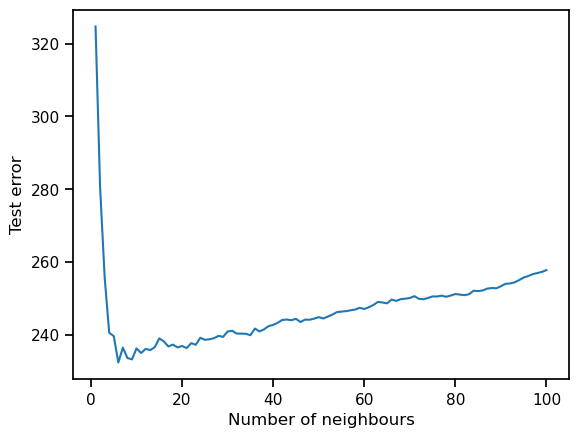

Lowest test error: K = 6


In [17]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

neighbours=np.arange(1, 101)
test_rmse = []
for k in neighbours: 
    knn = KNeighborsRegressor(n_neighbors = k) 
    knn.fit(train[['Limit']], train['Balance'])
    predictions = knn.predict(test[['Limit']])
    rmse = np.sqrt(mean_squared_error(test['Balance'], predictions))
    test_rmse.append(rmse)

fig, ax= plt.subplots()
ax.plot(neighbours, test_rmse, color='#1F77B4')
ax.set_xlabel('Number of neighbours')
ax.set_ylabel('Test error')
plt.show()

print('Lowest test error: K = {}'.format(1 + np.argmin(test_rmse)))

### KNN regression test performance
Now, let's add more predictors.

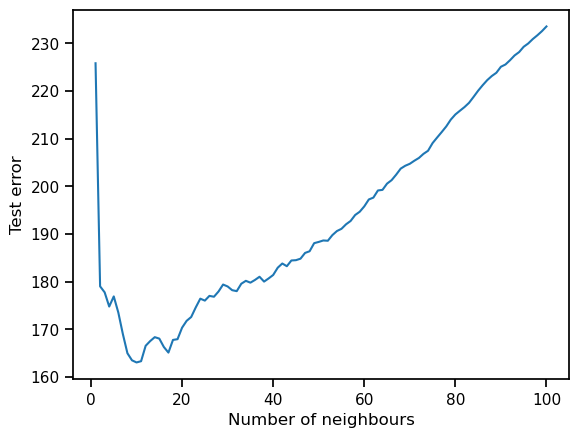

Lowest test error: K = 10


In [19]:
predictors=['Limit','Income']

neighbours=np.arange(1, 101)
test_rmse = []
for k in neighbours: 
    knn = KNeighborsRegressor(n_neighbors= k,  metric='mahalanobis', metric_params={'V': train[predictors].cov()}) 
    knn.fit(train[predictors], train['Balance'])
    predictions = knn.predict(test[predictors])
    rmse = np.sqrt(mean_squared_error(test['Balance'], predictions))
    test_rmse.append(rmse)

fig, ax= plt.subplots()
ax.plot(neighbours, test_rmse, color='#1F77B4')
ax.set_xlabel('Number of neighbours')
ax.set_ylabel('Test error')
plt.show()
                                   
print('Lowest test error: K = {}'.format(1 + np.argmin(test_rmse)))

Therefore, ``K=6`` neighbours has the best test performance for the model with only ``Limit`` as a predictor, and ``K=10`` has the best test performance for the model with ``Limit`` and ``Income`` as predictors. We can see that in this second case, the test performance deteriorates sharply as we increase ``K`` to be larger than the optimal number of neighbours.

However, in practice we need to **select the number of neighbours before taking the model to the test data**. 

Are we able to identify based on the training data that ``K`` around 6 and 7 is the best number of neighbours? We then turn to **cross validation**.

### Cross validation

The general procedure for computing the cross validation errors is the following: 

1. Set a cross validation iterator. This will set the number of folds and specify which observations are in each fold. 
2. Specify the model (without training it).
3. Use the [<TT>cross_validation_score</TT>](http://scikit-learn.org/stable/modules/model_evaluation.html) function to compute the cross validation errors. The output is the **score for each fold**. 

We will do this step by step. Suppose that we want to do 10-fold cross validation. The syntax for the [K-Fold CV](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) iterator is as follows. 

In [22]:
from sklearn.model_selection import KFold
kf=KFold(10) 
# Syntax: KFold(number of folds, shuffle=True/False, random_state = a number, if shuffling)

By default, the ``shuffle`` option is ``False``. That splits the data into folds according to the order of the observations, without randomisation. Setting it ``True`` splits the data randomly. 

It turns out that when we generated the training data, the function already returned a random permutation of the observations, based on ``random_state``, so that it would be unnecessary to shuffle again here. 

Remember that LOOCV is equivalent to K-Fold CV with K equal to the size of the training sample.

In [25]:
from sklearn.model_selection import LeaveOneOut
loo=LeaveOneOut()

We now compute the results for each fold, using the the 10-fold CV iterator. 

In [27]:
from sklearn.model_selection import cross_val_score

# Model- 5NN
knn = KNeighborsRegressor(n_neighbors= 5) 

# Syntax: cross_val_score(method, predictors, response, cv = number of folds, scoring = scoring function)
# 10 folder CV
scores = cross_val_score(knn, train[['Limit']], train['Balance'], cv=kf, scoring = 'neg_mean_squared_error')

# print the score for each fold
print(scores)

[ -80223.44714286 -122744.42571429  -45361.16142857  -14631.97857143
  -28697.30142857  -51502.29142857  -80393.41142857  -50706.58142857
  -30731.23571429  -12061.44857143]


**The scoring in scikit-learn follows the convention that higher score values are better than lower values**. This is why the **argument in the function is the negative mean squared error**. The scikit-learn [model evaluation](http://scikit-learn.org/stable/modules/model_evaluation.html) documentation provides a list of scoring options. You should save this for future reference.

Often, the syntax is simplified by the fact that each method in scikit-learn has a default scoring method. In this case you have to consult the documentation to know what it is. For a [KNN regression the default scoring is the r-squared](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor), allowing us to interpret the output below. 

In [29]:
scores = cross_val_score(knn, train[['Limit']], train['Balance'], cv=kf)
print(scores)

[0.65454382 0.54011848 0.80810047 0.91623641 0.84439011 0.66948834
 0.65190653 0.80374385 0.88182998 0.9219122 ]


Another option is to create a scorer using [<TT>make_scorer</TT>](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html#sklearn.metrics.make_scorer) function. In a general situation, we can then provide the same function that we we use for model evaluation.

In [31]:
from sklearn.metrics import make_scorer
scorer = make_scorer(mean_squared_error, greater_is_better=False)
scores = cross_val_score(knn, train[['Limit']], train['Balance'], cv=kf, scoring = scorer)
print(scores)

[ -80223.44714286 -122744.42571429  -45361.16142857  -14631.97857143
  -28697.30142857  -51502.29142857  -80393.41142857  -50706.58142857
  -30731.23571429  -12061.44857143]


Finally, in this case we could **directly specify the number of folds instead of the iterator**. The reason we started with the iterator is so that you know the full procedure.

In [33]:
scores = cross_val_score(knn, train[['Limit']], train['Balance'], cv=10,  scoring = 'neg_mean_squared_error')
print(scores)

[ -80223.44714286 -122744.42571429  -45361.16142857  -14631.97857143
  -28697.30142857  -51502.29142857  -80393.41142857  -50706.58142857
  -30731.23571429  -12061.44857143]


### Applying cross validation

In this section, we apply the cross validation to the previous model selection example. 

Now we try to complete the model selection job with cross validation.

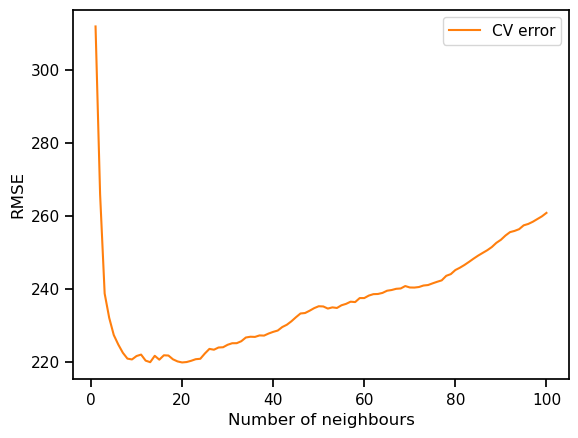

Lowest CV error: K = 20


In [35]:
neighbours=np.arange(1, 101)

cv_rmse = []
for k in neighbours: 
    knn = KNeighborsRegressor(n_neighbors= k) 
    scores = cross_val_score(knn, train[['Limit']], train['Balance'], cv=10, scoring = 'neg_mean_squared_error')
    # taking the average MSE across folds, then taking the square root to generate RMSE
    rmse = np.sqrt(-1*np.mean(scores)) 
    cv_rmse.append(rmse)
    knn.fit(train[['Limit']], train['Balance'])
    
fig, ax= plt.subplots()
ax.plot(neighbours, cv_rmse, color='#FF7F0E', label='CV error')
ax.set_xlabel('Number of neighbours')
ax.set_ylabel('RMSE')
plt.legend()
plt.show()
  
print('Lowest CV error: K = {}'.format(1 + np.argmin(cv_rmse)))   

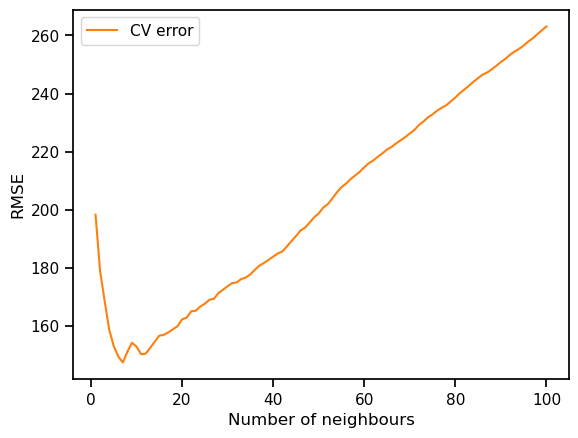

Lowest CV error: K = 7


In [36]:
predictors=['Limit','Income']

neighbours=np.arange(1, 101)
cv_rmse = []

for k in neighbours: 
    knn = KNeighborsRegressor(n_neighbors = k, metric='mahalanobis', metric_params={'V': train[predictors].cov()}) 
    scores = cross_val_score(knn, train[predictors], train['Balance'], cv=10, scoring = 'neg_mean_squared_error')
    rmse = np.sqrt(-1*np.mean(scores)) # taking the average MSE across folds, then taking the square root
    cv_rmse.append(rmse)
    knn.fit(train[predictors], train['Balance'])

fig, ax= plt.subplots()
ax.plot(neighbours, cv_rmse, color='#FF7F0E', label='CV error')
ax.set_xlabel('Number of neighbours')
ax.set_ylabel('RMSE')
plt.legend()
plt.show()
  
print('Lowest CV error: K = {}'.format(1 + np.argmin(cv_rmse)))   

### Adding predictors

So far, we have been using ``Limit`` and ``Income`` on the basis that they are the two predictors with highest correlation with the response. We should consider including more predictors to improve our predictions. 

In [38]:
train.corr().round(3)['Balance']

Income       0.531
Limit        0.882
Cards        0.076
Age         -0.029
Education   -0.020
Student      0.240
Married     -0.015
Balance      1.000
Male         0.017
Caucasian   -0.067
Asian       -0.008
Name: Balance, dtype: float64

A note of caution here: the correlations only tell us about linear relationships. We should also use exploratory plots as before to discover nonlinear patterns, which the KNN method is able to capture.  

The best way to proceed is to write a function that:
1. Takes a list of predictors.
2. Selects the optimal number of neighbors via cross-validation.
3. Refits the optimal KNN model on the whole training data set.
3. Evaluates the model on the test set.

In [40]:
def knn_test(predictors, response):
    
    neighbours=np.arange(1, 51)
    best_score = -np.inf
    
    for k in neighbours: 
        knn = KNeighborsRegressor(n_neighbors = k, metric='mahalanobis', metric_params={'V': train[predictors].cov()}) 
        scores = cross_val_score(knn, train[predictors], train[response], cv=10, scoring = 'neg_mean_squared_error')
        # taking the average of scores across 10 folds
        cv_score = np.mean(scores)
        # use the cv score for model selection
        if cv_score >= best_score:
            best_score = cv_score
            best_knn = knn
    
    knn = best_knn
    # train the selected model with the whole train set
    knn.fit(train[predictors], train[response])
    # Predict the test data with the selected and re-estimated model
    predictions = knn.predict(test[predictors])
    test_rmse = np.sqrt(mean_squared_error(test[response], predictions))
    cv_rmse= np.sqrt(-best_score)
    print('Chosen K: {}'.format(knn.n_neighbors))
    
    return test_rmse, cv_rmse 

The next two cells compute the results for the choices of predictors that we had so far.

In [42]:
# Note: the Mahalanobis distance will lead to the same result as the Euclidean distance when there is only one predictor

response='Balance'
predictors=['Limit']
test_rmse, cv_rmse  =  knn_test(predictors, response) 
print('Test RMSE : {}'.format(test_rmse.round(2)))
print('Cross validation RMSE : {}'.format(cv_rmse.round(2)))

Chosen K: 20
Test RMSE : 236.82
Cross validation RMSE : 219.87


In [43]:
response='Balance'
predictors=['Limit','Income']
test_rmse, cv_rmse  =  knn_test(predictors, response) 
print('Test RMSE : {}'.format(test_rmse.round(2)))
print('Cross validation RMSE : {}'.format(cv_rmse.round(2)))

Chosen K: 7
Test RMSE : 168.98
Cross validation RMSE : 147.39


The third predictor with highest correlation with balance is student. Student in a categorical variable, which introduces new considerations as to how to combine continuous and dummy variables in the distance metric. We follow a simple approach and treat the dummy variable as any other. 

The results show that introducing student as a predictor lead to substantial improvements in the test error. The cross validation errors would lead use to select this specification over the previous ones, e.g.77.2 vs 147.39. 

In [45]:
response='Balance'
predictors=['Limit','Income', 'Student']
test_rmse, cv_rmse  =  knn_test(predictors, response) 
print('Test RMSE : {}'.format(test_rmse.round(2)))
print('Cross validation RMSE : {}'.format(cv_rmse.round(2)))

Chosen K: 4
Test RMSE : 67.93
Cross validation RMSE : 77.2


How about using even more predictors, maybe all of them? 

The results suggest that adding more predictors can be counterproductive. If we try to use all the variables, the predictions sharply deteriorate due to **overfitting** and the **curse of dimensionality**. In such cases, it is advisable to keep the number of neighbors K low in KNN models. Fortunately, cross-validation indicated that the best model uses only ``Limit``, ``Income``, and ``Student`` as predictors, helping to avoid these issues.


In [47]:
response='Balance'
predictors=['Limit','Income', 'Student', 'Cards']
test_rmse, cv_rmse  =  knn_test(predictors, response) 
print('Test RMSE : {}'.format(test_rmse.round(2)))
print('Cross validation RMSE : {}'.format(cv_rmse.round(2)))

Chosen K: 5
Test RMSE : 90.07
Cross validation RMSE : 105.5


In [48]:
response='Balance'
predictors=['Limit','Income', 'Student', 'Cards', 'Age', 'Education', 'Married', 'Male', 'Caucasian', 'Asian']
test_rmse, cv_rmse  =  knn_test(predictors, response) 
print('Test RMSE : {}'.format(test_rmse.round(2)))
print('Cross validation RMSE : {}'.format(cv_rmse.round(2)))

Chosen K: 4
Test RMSE : 259.83
Cross validation RMSE : 272.96


### Computational considerations

Note that our training set is relatively small, with only 280 samples. Many of the computational tasks we performed in this tutorial could have a high computational cost, potentially prohibitive in larger datasets.  It’s important to be mindful of potential bottlenecks and consider more efficient approaches or algorithms when working with larger datasets.


### The next step

In the previous section, we used an informal approach to include predictors, testing only a few possible combinations. This raises the question of whether we might be missing important predictors or combinations. To address this systematically, we turn to the next topic - variable selection (subset selection) methods, which we will study in the context of linear regression.
